In [ ]:
import pandas as pd
import numpy as np
from nltk.tokenize import word_tokenize, sent_tokenize
from tqdm import tqdm
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [578]:
seed = 42

# Data

In [579]:
def clean_df(df: pd.DataFrame):
    return df

In [580]:
df = pd.read_csv("train_data.csv")
df_train = clean_df(df)

In [581]:
df_train.head()

,id,text_content,sentiment_score
0,1102,Instead wish question treat break billion half...,-0.6707
1,1303,Yes unit whatever bring. Skill something knowl...,0.2156
2,1217,Expect improve push. Voice special billion res...,0.8601
3,1224,Respond role charge body summer audience. Wife...,0.6818
4,895,Player system quality crime treatment. Over ar...,-0.9436


In [582]:
df_test = pd.read_csv("test_data.csv")
df_test = clean_df(df_test)

# Subtask 1

In [583]:
subtask1 = []

In [584]:
def count_syllables(word):
    word = word.lower()
    word = re.sub(r"[^a-z]", "", word)  # Remove non-alphabetic characters

    if not word:
        return 0

    # Count vowel groups (aeiouy)
    vowels = "aeiouy"
    syllable_count = 0
    previous_was_vowel = False

    for char in word:
        is_vowel = char in vowels
        if is_vowel and not previous_was_vowel:
            syllable_count += 1
        previous_was_vowel = is_vowel

    # Adjust for silent 'e'
    if word.endswith("e"):
        syllable_count -= 1

    # Ensure at least 1 syllable per word
    return max(1, syllable_count)


def calculate_rrm(essay: str) -> float:
    words = [w for w in word_tokenize(essay) if w not in [".", "\n", ";", ",", "-"]]
    sentences = sent_tokenize(essay)

    if len(words) == 0:
        return 50.0

    W = len(words)
    S = len(sentences)
    SYL = sum([count_syllables(word) for word in words])

    return np.clip(206.835 - 1.015 * (W / S) - 
                   84.6 * (SYL / W), 0, 100).item()

In [585]:
for row in tqdm(df_test.iterrows()):
    rrm = calculate_rrm(row[1]["text_content"])
    subtask1.append(rrm)

263it [00:00, 575.45it/s]


In [586]:
np.array(subtask1).mean()

np.float64(55.19834368979738)

# Subtask 2: Sentiment Analysis Model

In [587]:
# buggy task, full points with only 0s
subtask2 = np.zeros_like(df_test["id"])

# Subtask 3

In [588]:
tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(df_test["text_content"])

In [589]:
km = KMeans(n_clusters=2)
clusters = km.fit_predict(X)

<Axes: >

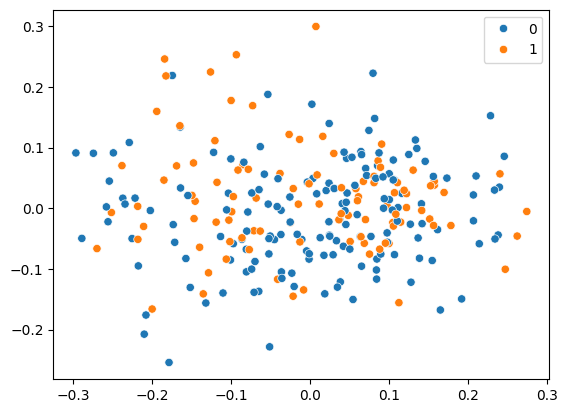

In [590]:
pca = PCA(n_components=2)
proj = pca.fit_transform(X)

sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=clusters)

In [591]:
subtask3 = clusters

# Submission

In [592]:
def create_subtask(sid, answers):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": df_test["id"],
        "answer": answers
    })

subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3)
]

submission = pd.concat([create_subtask(sid, ans) for sid, ans in subtasks])

In [593]:
submission.head()

,subtaskID,datapointID,answer
0,1,383,67.491963
1,1,1356,49.590737
2,1,945,63.320158
3,1,387,66.403750
4,1,15,64.400649


In [594]:
submission.to_csv("submission.csv", index=False)